In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pandas as pd
import numpy as np

from torchmetrics.classification import MulticlassRecall
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [28]:
root_path = "/home/stefan/ioai-prep/kits/neoai/find_comments"
device = "cuda"
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

In [29]:
model_name = "deepvk/USER2-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
transformer = AutoModel.from_pretrained(model_name)

# Data

In [30]:
train = pd.read_csv(f'{root_path}/train_texts.csv').dropna()
test = pd.read_csv(f"{root_path}/test_texts.csv")

train.head()

,text,target
0,Самая важная информация \n \n⚡️\n\n\n\nЭто — с...,0
1,"Мы хотим, чтобы сообщество было безопасным и д...",0
2,Welcome on board\n \n⚡️\n\n\nНачинаем наше зна...,0
3,"оо, вижу первых обладателей гранта в этом сезо...",59
4,Грант останется,44


<Axes: xlabel='target'>

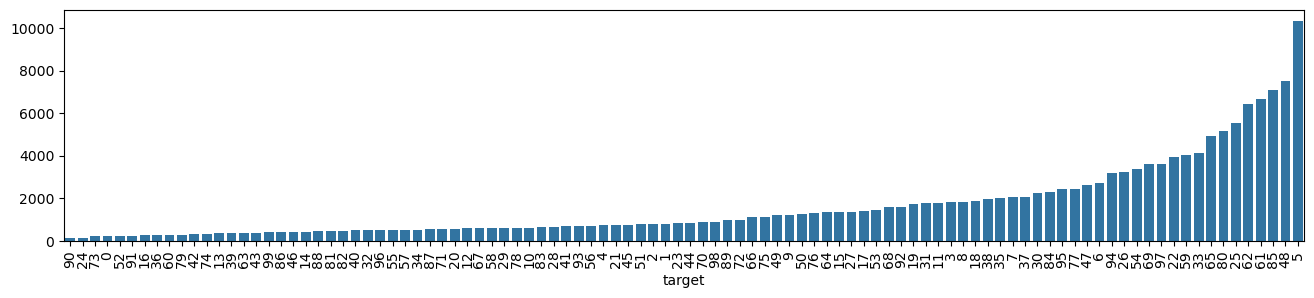

In [31]:
plt.figure(figsize=(16,3))
plt.tick_params("x", rotation=90)

data = train["target"].value_counts(ascending=True)
sns.barplot(x=data.index, y=data.values, order=data.index)

In [32]:
def time_based_split(train, val_frac=0.2):
    val_indices = []
    for tgt in sorted(train["target"].unique()):
        tgt_idxs = train.index[train["target"] == tgt].tolist()
        n_val = max(1, int(len(tgt_idxs) * val_frac))
        val_indices.extend(tgt_idxs[-n_val:])
    val_mask = train.index.isin(val_indices)
    return (
        train[~val_mask].reset_index(drop=True),
        train[val_mask].reset_index(drop=True),
    )

df_train, df_val = time_based_split(train)
y_train = df_train["target"]
y_val = df_val["target"]

print(f"Train: {len(df_train)}, Val: {len(df_val)}")
print(f"Val text length mean: {df_val['text'].str.len().mean():.0f}")

Train: 130728, Val: 32635
Val text length mean: 34


In [33]:
def get_cb_weights(labels, beta=0.9999, device="cpu"):
    label_counts = pd.Series(labels).value_counts().sort_index().values
    effective_num = (1.0 - np.power(beta, label_counts)) / (1.0 - beta)
    weights = 1.0 / effective_num
    weights = weights / np.sum(weights) * len(label_counts)
    return torch.tensor(weights, dtype=torch.float32).to(device)

class_weights = get_cb_weights(y_train, beta=0.9999, device=device)
print(f"Class weight range: {class_weights.min():.2f} - {class_weights.max():.2f}")

Class weight range: 0.09 - 5.53


In [34]:
class AuthorDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        encoded = tokenizer(
            [str(t) for t in texts],
            max_length=max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
        self.input_ids = encoded["input_ids"]
        self.attention_mask = encoded["attention_mask"]
        self.labels = torch.tensor(labels.values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.attention_mask[idx], self.labels[idx]

In [35]:
train_dataset = AuthorDataset(df_train["text"].values, y_train, tokenizer)
val_dataset = AuthorDataset(df_val["text"].values, y_val, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Model

In [36]:
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * mask, 1) / torch.clamp(mask.sum(1), min=1e-9)

num_classes = 100

n_layers = len(transformer.layers)
print(f"Transformer layers: {n_layers}")

for i, layer in enumerate(transformer.layers):
    for param in layer.parameters():
        param.requires_grad = True

trainable_params = sum(
    p.numel() for p in transformer.parameters() if p.requires_grad
)
total_params = sum(p.numel() for p in transformer.parameters())
print(f"Transformer trainable: {trainable_params:,} / {total_params:,}")

Transformer layers: 12
Transformer trainable: 34,391,424 / 34,391,424


In [37]:
class AuthorClassifier(nn.Module):
    def __init__(self, transformer, num_classes, hidden_dim=512):
        super().__init__()
        self.transformer = transformer
        embed_dim = transformer.config.hidden_size
        self.head = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        emb = mean_pooling(outputs, attention_mask)
        return self.head(emb)


model = AuthorClassifier(transformer, num_classes).to(device)
print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

Model params: 34,640,868


In [38]:
transformer_params = [p for p in model.transformer.parameters() if p.requires_grad]
head_params = list(model.head.parameters())

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0,
)

optimizer = torch.optim.AdamW(
    [
        {"params": transformer_params, "lr": 5e-5},
        {"params": head_params, "lr": 5e-4},
    ],
    weight_decay=1e-2,
)

epochs = 20

r5_metric = MulticlassRecall(num_classes=num_classes, top_k=5).to(device)
scaler_amp = torch.amp.GradScaler("cuda")

best_r5 = 0
best_epoch = 0
best_state = None
patience_counter = 0
max_patience = 2

In [39]:
for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch:2d}")
    for input_ids, attention_mask, labels in pbar:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler_amp.step(optimizer)
        scaler_amp.update()

        train_loss += loss.item() * input_ids.size(0)
        pbar.set_postfix({"loss": f"{loss.item():.3f}"})

    train_loss /= len(train_dataset)

    model.eval()
    val_loss = 0.0
    r5_metric.reset()
    with torch.no_grad():
        for input_ids, attention_mask, labels in val_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)
            with torch.amp.autocast("cuda"):
                logits = model(input_ids, attention_mask)
                val_loss += criterion(logits, labels).item() * input_ids.size(0)
            r5_metric.update(F.softmax(logits.float(), dim=1), labels)

    val_loss /= len(val_dataset)
    val_r5 = r5_metric.compute().item()
    print(
        f"epoch {epoch:2d}: t_loss={train_loss:.3f},"
        f" v_loss={val_loss:.3f}, v_R@5={val_r5:.4f}"
    )

    if val_r5 > best_r5:
        best_r5 = val_r5
        best_epoch = epoch
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= max_patience:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch  1: 100%|██████████| 2042/2042 [01:24<00:00, 24.08it/s, loss=3.730]


epoch  1: t_loss=3.855, v_loss=3.850, v_R@5=0.2841


Epoch  2: 100%|██████████| 2042/2042 [01:25<00:00, 23.92it/s, loss=2.658]


epoch  2: t_loss=3.213, v_loss=3.865, v_R@5=0.3013


Epoch  3: 100%|██████████| 2042/2042 [01:26<00:00, 23.59it/s, loss=3.091]


epoch  3: t_loss=2.475, v_loss=4.180, v_R@5=0.2919


Epoch  4: 100%|██████████| 2042/2042 [01:25<00:00, 23.79it/s, loss=1.738]


epoch  4: t_loss=1.708, v_loss=4.849, v_R@5=0.2701
Early stopping at epoch 4


In [40]:
model.load_state_dict(best_state)
model.eval()
r5_metric.reset()
with torch.no_grad():
    for input_ids, attention_mask, labels in val_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)
        with torch.amp.autocast("cuda"):
            logits = model(input_ids, attention_mask)
        r5_metric.update(F.softmax(logits.float(), dim=1), labels)

final_val_r5 = r5_metric.compute().item()
print(
    f"Best Val R@5: {best_r5:.4f} (epoch {best_epoch})"
    f"  |  Final Val R@5: {final_val_r5:.4f}"
)

Best Val R@5: 0.3013 (epoch 2)  |  Final Val R@5: 0.3013


# Submission

In [41]:
test_dataset = AuthorDataset(
    test["text"].values,
    pd.Series(np.zeros(len(test), dtype=int)),
    tokenizer,
)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

all_probs = []
model.eval()
with torch.no_grad():
    for input_ids, attention_mask, _ in tqdm(test_loader, desc="Predict"):
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        with torch.amp.autocast("cuda"):
            logits = model(input_ids, attention_mask)
        all_probs.append(F.softmax(logits.float(), dim=1).cpu().numpy())

probs = np.concatenate(all_probs, axis=0)
top5_indices = np.argsort(probs, axis=1)[:, -5:][:, ::-1]
predictions = [" ".join(map(str, row)) for row in top5_indices]

submission_df = pd.DataFrame(
    {"index": np.arange(0, 5000).tolist(), "target": predictions}
)

Predict: 100%|██████████| 20/20 [00:00<00:00, 40.49it/s]


In [42]:
submission_df.head()

,index,target
0,0,4 63 46 98 29
1,1,4 7 43 63 23
2,2,8 90 15 62 47
3,3,4 40 82 63 76
4,4,4 97 21 75 63


In [43]:
submission_df.to_csv(f"{root_path}/submission.csv", index=False)